Cell 1 - Imports and Data

In [9]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Synthetic employee data — all names anonymized to protect privacy
# Positions reflect actual role distribution in a multi-location retail organization
employees = [
    {"name": "Employee_01", "position": "Outside Sales"},
    {"name": "Employee_02", "position": "Assistant Manager"},
    {"name": "Employee_03", "position": "Sales Associate"},
    {"name": "Employee_04", "position": "General Manager"},
    {"name": "Employee_05", "position": "Assistant Manager"},
    {"name": "Employee_06", "position": "General Manager"},
    {"name": "Employee_07", "position": "Sales Associate"},
    {"name": "Employee_08", "position": "Outside Sales"},
    {"name": "Employee_09", "position": "Outside Sales"},
    {"name": "Employee_10", "position": "Sales Associate"},
    {"name": "Employee_11", "position": "General Manager"},
    {"name": "Employee_12", "position": "Sales Associate"},
    {"name": "Employee_13", "position": "Sales Associate"},
    {"name": "Employee_14", "position": "Sales Associate"},
    {"name": "Employee_15", "position": "Sales Associate"}
]

# Generate reproducible synthetic data
np.random.seed(0)
num_employees = len(employees)

data = {
    "Name": [e["name"] for e in employees],
    "Position": [e["position"] for e in employees],
    "Customer Satisfaction": np.random.randint(70, 100, num_employees),
    "Performance Ratings": np.random.randint(1, 5, num_employees),
    "Training Hours Completed": np.random.randint(5, 50, num_employees),
    "Scores from Training Assessments": np.random.randint(50, 100, num_employees),
    "Types of Training Completed": np.random.choice(
        ['Sales', 'Customer Service', 'Management', 'Technical'], num_employees),
    "Attendance Records": np.random.randint(90, 100, num_employees),
    "Feedback from Peers and Managers": np.random.choice(
        ['Positive', 'Neutral', 'Negative'], num_employees),
    "Readiness for Managerial Roles": np.random.choice(
        ['High', 'Medium', 'Low'], num_employees),
    "Need for Further Training or Support": np.random.choice(
        ['Yes', 'No'], num_employees),
    "Strengths and Areas for Improvement": np.random.choice([
        'Strength in Sales',
        'Needs Improvement in Technical Skills',
        'Good Leadership Qualities',
        'Needs Improvement in Customer Service'
    ], num_employees)
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Dataset shape: (15, 12)

First 5 rows:


,Name,Position,Customer Satisfaction,Performance Ratings,Training Hours Completed,Scores from Training Assessments,Types of Training Completed,Attendance Records,Feedback from Peers and Managers,Readiness for Managerial Roles,Need for Further Training or Support,Strengths and Areas for Improvement
0,Employee_01,Outside Sales,82,1,14,51,Sales,93,Positive,High,Yes,Good Leadership Qualities
1,Employee_02,Assistant Manager,85,1,25,59,Sales,96,Positive,Medium,No,Needs Improvement in Customer Service
2,Employee_03,Sales Associate,91,1,21,82,Customer Service,97,Negative,Low,Yes,Strength in Sales
3,Employee_04,General Manager,70,3,10,81,Technical,92,Positive,High,No,Needs Improvement in Technical Skills
4,Employee_05,Assistant Manager,73,2,20,60,Sales,90,Negative,Low,No,Good Leadership Qualities


Cell 2  - Preprocessing

In [10]:
# Encode categorical columns
# Note: LabelEncoder assigns arbitrary numeric values to categories.
# This is appropriate here since we are using the encoded values only
# as inputs to an unsupervised clustering algorithm, not making
# predictions where ordinal relationships matter.

df_encoded = df.copy()
label_encoders = {}

for column in df_encoded.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df_encoded[column] = label_encoders[column].fit_transform(df_encoded[column])

# Extract features (exclude Name and Position from clustering)
features = df_encoded.drop(columns=['Name', 'Position'])

# Standardize — critical step so no single feature dominates due to scale
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print("Features used for clustering:")
for col in features.columns:
    print(f"  - {col}")
print(f"\nScaled feature matrix shape: {scaled_features.shape}")

Features used for clustering:
  - Customer Satisfaction
  - Performance Ratings
  - Training Hours Completed
  - Scores from Training Assessments
  - Types of Training Completed
  - Attendance Records
  - Feedback from Peers and Managers
  - Readiness for Managerial Roles
  - Need for Further Training or Support
  - Strengths and Areas for Improvement

Scaled feature matrix shape: (15, 10)


Cell 3 - PCA

In [11]:
# Apply PCA to reduce to 2 components for visualization
# PCA finds the directions of maximum variance in the data
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PCA1', 'PCA2']
)

# Variance explained — how much information is retained
variance_explained = pca.explained_variance_ratio_
print(f"Variance explained by PCA1: {variance_explained[0]:.1%}")
print(f"Variance explained by PCA2: {variance_explained[1]:.1%}")
print(f"Total variance retained:    {sum(variance_explained):.1%}")


Variance explained by PCA1: 27.5%
Variance explained by PCA2: 18.9%
Total variance retained:    46.4%


Cell 4 - PCA Component Weights

In [12]:
# Which features drive each principal component?
# High absolute values = strong influence on that component
pca_weights = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features.columns
)

print("PCA Component Weights (feature loadings):")
print("Positive = increases along that axis | Negative = decreases along that axis")
print()
print(pca_weights.round(3).to_string())
print()
print("Interpretation:")
print("  PCA1 — Customer-Facing Performance axis")
print("         Driven by: Customer Satisfaction (+), Strengths/Improvement (+)")
print("         Opposed by: Training Type (-), Peer/Manager Feedback (-)")
print()
print("  PCA2 — Development Readiness axis")
print("         Driven negatively by: Managerial Readiness (-), Training Scores (-),")
print("         Need for Further Training (-)")
print("         (Lower PCA2 = higher development need)")


PCA Component Weights (feature loadings):
Positive = increases along that axis | Negative = decreases along that axis

                                       PCA1   PCA2
Customer Satisfaction                 0.399  0.274
Performance Ratings                  -0.195  0.045
Training Hours Completed              0.266 -0.295
Scores from Training Assessments     -0.126 -0.484
Types of Training Completed          -0.528 -0.098
Attendance Records                    0.277 -0.244
Feedback from Peers and Managers     -0.406  0.153
Readiness for Managerial Roles       -0.113 -0.548
Need for Further Training or Support  0.076 -0.450
Strengths and Areas for Improvement   0.422 -0.077

Interpretation:
  PCA1 — Customer-Facing Performance axis
         Driven by: Customer Satisfaction (+), Strengths/Improvement (+)
         Opposed by: Training Type (-), Peer/Manager Feedback (-)

  PCA2 — Development Readiness axis
         Driven negatively by: Managerial Readiness (-), Training Scores (-),
       

Cell 5 - Elbow Curve

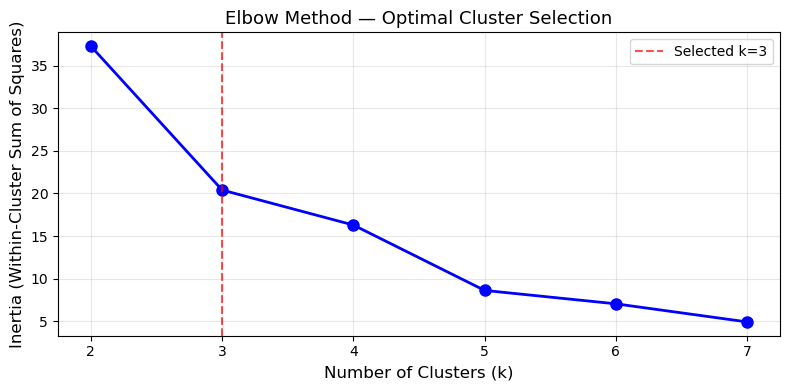

k=3 selected: elbow visible at k=3, diminishing returns beyond that point.
In a production deployment, this would be validated against actual
performance outcome data over time.


In [13]:
# Elbow method to justify k=3 cluster selection
# Inertia = sum of squared distances from each point to its cluster center
# We look for the "elbow" where adding more clusters yields diminishing returns

inertias = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=0)
    km.fit(pca_df[['PCA1', 'PCA2']])
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Selected k=3')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method — Optimal Cluster Selection', fontsize=13)
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("k=3 selected: elbow visible at k=3, diminishing returns beyond that point.")
print("In a production deployment, this would be validated against actual")
print("performance outcome data over time.")


Cell 6 - Clustering

In [14]:
# Apply K-Means clustering to PCA-reduced feature space
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=0)
clusters = kmeans.fit_predict(pca_df[['PCA1', 'PCA2']])

pca_df['Cluster'] = clusters
pca_df['Name'] = df['Name']
pca_df['Position'] = df['Position']

print("Cluster assignments:")
print(pca_df[['Name', 'Position', 'Cluster']].to_string(index=False))
print()
print("Cluster sizes:")
print(pca_df['Cluster'].value_counts().sort_index())

Cluster assignments:
       Name          Position  Cluster
Employee_01     Outside Sales        0
Employee_02 Assistant Manager        0
Employee_03   Sales Associate        1
Employee_04   General Manager        0
Employee_05 Assistant Manager        0
Employee_06   General Manager        2
Employee_07   Sales Associate        0
Employee_08     Outside Sales        1
Employee_09     Outside Sales        0
Employee_10   Sales Associate        1
Employee_11   General Manager        2
Employee_12   Sales Associate        1
Employee_13   Sales Associate        0
Employee_14   Sales Associate        2
Employee_15   Sales Associate        1

Cluster sizes:
Cluster
0    7
1    5
2    3
Name: count, dtype: int64


Cell 7 - Scatter Plot

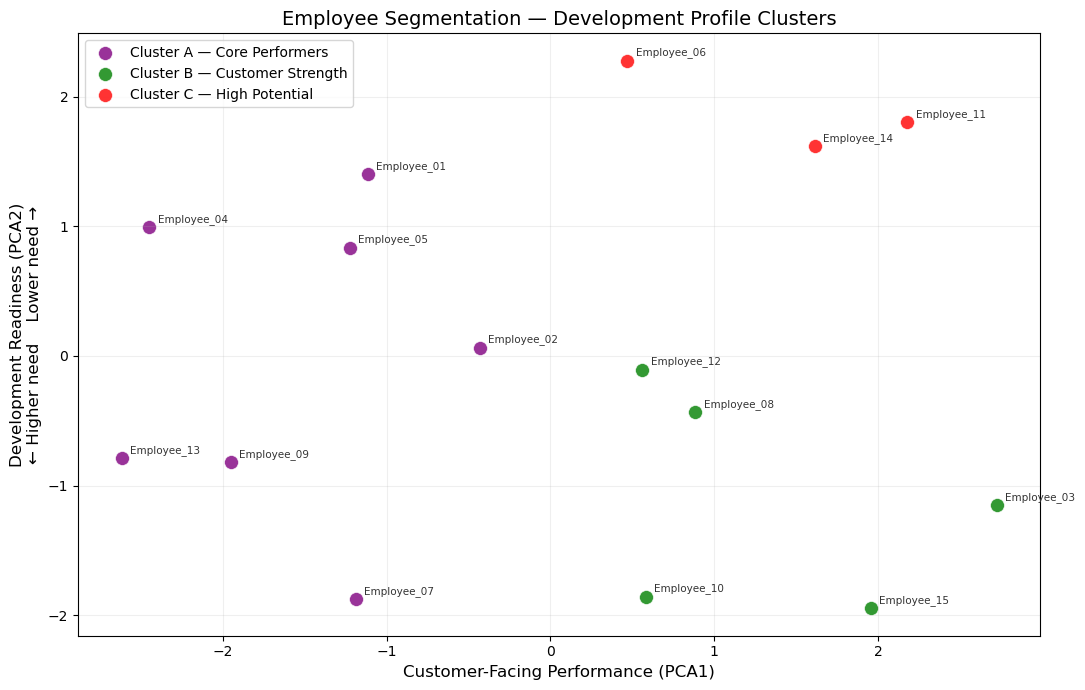

In [15]:
# Color mapping for interpretable cluster labels
cluster_colors = {0: 'purple', 1: 'green', 2: 'red'}
cluster_names = {
    0: 'Cluster A — Core Performers',
    1: 'Cluster B — Customer Strength',
    2: 'Cluster C — High Potential'
}

plt.figure(figsize=(11, 7))

for cluster_id, group in pca_df.groupby('Cluster'):
    plt.scatter(
        group['PCA1'],
        group['PCA2'],
        c=cluster_colors[cluster_id],
        label=cluster_names[cluster_id],
        s=100,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.5
    )

# Annotate with employee labels (not index numbers)
for _, row in pca_df.iterrows():
    plt.annotate(
        row['Name'],
        (row['PCA1'], row['PCA2']),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=7.5,
        color='#333333'
    )

plt.xlabel('Customer-Facing Performance (PCA1)', fontsize=12)
plt.ylabel('Development Readiness (PCA2)\n← Higher need    Lower need →',
           fontsize=12)
plt.title('Employee Segmentation — Development Profile Clusters', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


Cell 8  - Cluster Summary and Development Recommendations

In [16]:
# Translate cluster assignments into plain-English development recommendations
# This is the governance layer — model output informs human decisions,
# it does not replace them.

cluster_profiles = {
    0: {
        "label": "Core Performers",
        "description": "Solid attendance and customer satisfaction. Mixed training "
                       "completion and feedback signals.",
        "recommendation": "Targeted skill-building interventions. Focus on training "
                          "completion and peer feedback quality.",
        "flag": "Monitor for burnout signals — strong performers often under-supported."
    },
    1: {
        "label": "Customer Strength — Development Needed",
        "description": "High customer-facing performance. Lower managerial readiness "
                       "and training assessment scores.",
        "recommendation": "Role mastery reinforcement. Not yet ready for promotion — "
                          "build structured path toward readiness.",
        "flag": "Risk of plateau without clear development path."
    },
    2: {
        "label": "High Potential",
        "description": "Strong across customer satisfaction and readiness indicators. "
                       "Peer/manager feedback positive.",
        "recommendation": "Accelerated leadership development track. Succession "
                          "planning candidates.",
        "flag": "Retention risk — these employees have options. Engage proactively."
    }
}

print("=" * 70)
print("EMPLOYEE DEVELOPMENT CLUSTER REPORT")
print("Generated by: Employee Segmentation Model (K-Means + PCA)")
print("Note: All recommendations require human review before action.")
print("=" * 70)

for cluster_id, profile in cluster_profiles.items():
    members = pca_df[pca_df['Cluster'] == cluster_id]['Name'].tolist()
    print(f"\nCLUSTER {cluster_id} — {profile['label']} ({len(members)} employees)")
    print(f"  Profile:        {profile['description']}")
    print(f"  Recommendation: {profile['recommendation']}")
    print(f"  Flag:           {profile['flag']}")
    print(f"  Members:        {', '.join(members)}")

print("\n" + "=" * 70)
print("GOVERNANCE NOTE")
print("=" * 70)
print("""
This output is designed to inform — not automate — development decisions.

Before any action is taken based on cluster assignments:
  1. HR leadership reviews cluster assignments for anomalies
  2. Direct managers validate cluster placement against lived experience
  3. Employees are informed of development track recommendations
  4. Cluster output is NOT used for compensation, promotion, or termination

This model reflects a point-in-time snapshot. Employee development is dynamic.
Re-run quarterly with updated performance data.
""")

EMPLOYEE DEVELOPMENT CLUSTER REPORT
Generated by: Employee Segmentation Model (K-Means + PCA)
Note: All recommendations require human review before action.

CLUSTER 0 — Core Performers (7 employees)
  Profile:        Solid attendance and customer satisfaction. Mixed training completion and feedback signals.
  Recommendation: Targeted skill-building interventions. Focus on training completion and peer feedback quality.
  Flag:           Monitor for burnout signals — strong performers often under-supported.
  Members:        Employee_01, Employee_02, Employee_04, Employee_05, Employee_07, Employee_09, Employee_13

CLUSTER 1 — Customer Strength — Development Needed (5 employees)
  Profile:        High customer-facing performance. Lower managerial readiness and training assessment scores.
  Recommendation: Role mastery reinforcement. Not yet ready for promotion — build structured path toward readiness.
  Flag:           Risk of plateau without clear development path.
  Members:        Empl